
# **PROJECT: MEDICAL INSURANCE COST PREDICTION**


# **PHASE 1 — Understand the problem**

In [28]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 

plt.rcParams['figure.figsize'] = (10, 6) 
print('Libraries imported successfully!') 

Libraries imported successfully!


# Load the Dataset:

In [29]:
df = pd.read_csv('insurance.csv')

# **PHASE 2 — DATASET COLLECTION & EXPLORATION**

In [30]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [31]:
df.shape

(1338, 7)

In [32]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [33]:
df.info

<bound method DataFrame.info of       age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]>

In [34]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


# **PHASE 3 — Data Cleaning & Preprocessing**


 **Check the missing values in the dataset.**
 **Missing values analysis and percentage:**


In [35]:
print("Missing values count per column:")
print(df.isnull().sum())

Missing values count per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [36]:
print("\nMissing values percentage:")
print((df.isnull().sum() / len(df)) * 100)


Missing values percentage:
age         0.0
sex         0.0
bmi         0.0
children    0.0
smoker      0.0
region      0.0
charges     0.0
dtype: float64


**Check the duplicate data in dataset.**

Duplicate analysis, check the duplicate data in column, and remove the duplicate data.

In [37]:
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows found: {duplicate_count}")

Total duplicate rows found: 1


In [38]:
if duplicate_count > 0:
    print("\nDuplicate Rows:")
    print(df[df.duplicated()])


Duplicate Rows:
     age   sex    bmi  children smoker     region    charges
581   19  male  30.59         0     no  northwest  1639.5631


In [39]:
df = df.drop_duplicates().reset_index(drop=True)
print(f"\nDataset shape after removing duplicates: {df.shape}")


Dataset shape after removing duplicates: (1337, 7)


**before and after preprocessing**

In [40]:
print("Data types after preprocessing:")
print(df.dtypes)

print(f"\nFinal cleaned dataset shape: {df.shape}")

Data types after preprocessing:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Final cleaned dataset shape: (1337, 7)


**Encoded categorical variables**

In [41]:
# Binary Encoding 
df['sex'] = df['sex'].map({'female': 0, 'male': 1})
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})

# One-Hot Encoding for 'region' 
df = pd.get_dummies(df, columns=['region'], drop_first=True, dtype=int)

print("Encoded Dataset Head:")
print(df.head())

Encoded Dataset Head:
   age  sex     bmi  children  smoker      charges  region_northwest  \
0   19    0  27.900         0       1  16884.92400                 0   
1   18    1  33.770         1       0   1725.55230                 0   
2   28    1  33.000         3       0   4449.46200                 0   
3   33    1  22.705         0       0  21984.47061                 1   
4   32    1  28.880         0       0   3866.85520                 1   

   region_southeast  region_southwest  
0                 0                 1  
1                 1                 0  
2                 1                 0  
3                 0                 0  
4                 0                 0  


**Final dataset prepared for ML**

In [42]:
X = df.drop(columns=['charges'])
y = df['charges']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

df.to_csv('cleaned_insurance.csv', index=False)
print("\nCleaned dataset saved as 'cleaned_insurance.csv' successfully!")

Features (X) shape: (1337, 8)
Target (y) shape: (1337,)

Cleaned dataset saved as 'cleaned_insurance.csv' successfully!


# **PHASE 4 — Exploratory Data Analysis**

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11
df = pd.read_csv('insurance.csv')
print("Dataset is successfully loaded.")

Dataset is successfully loaded.


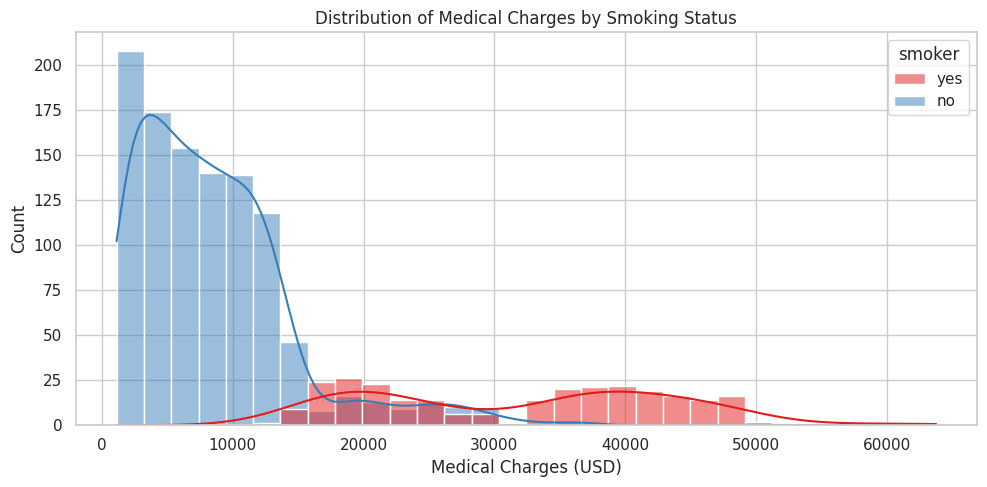

In [ ]:
# --- VISUALIZATION 1: Target Distribution & Smoking Impact ---
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='charges', hue='smoker', kde=True, bins=30, palette='Set1')
plt.title('Distribution of Medical Charges by Smoking Status')
plt.xlabel('Medical Charges (USD)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('chart1_charges_by_smoker.png')
plt.show()

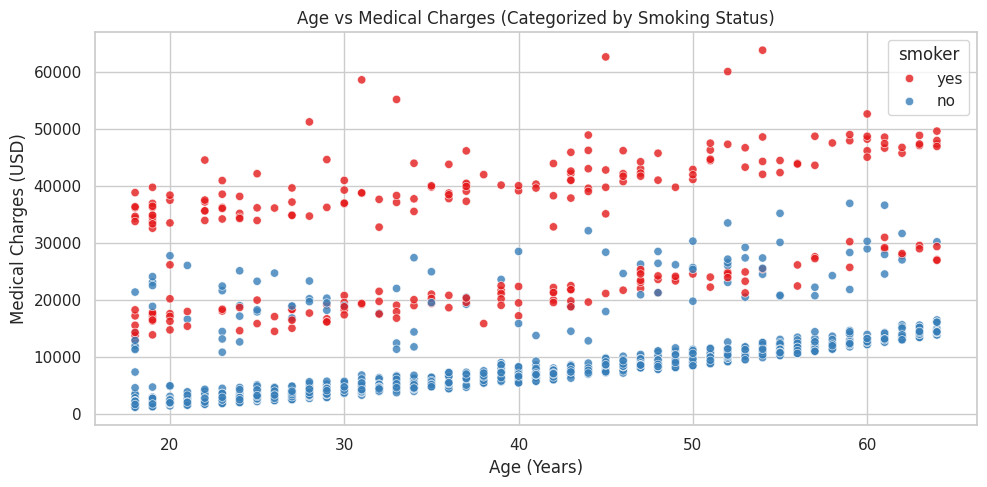

In [ ]:
# --- VISUALIZATION 2: Age vs. Charges Scatter Plot ---
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', palette='Set1', alpha=0.8)
plt.title('Age vs Medical Charges (Categorized by Smoking Status)')
plt.xlabel('Age (Years)')
plt.ylabel('Medical Charges (USD)')
plt.tight_layout()
plt.savefig('chart2_age_vs_charges.png')
plt.show()

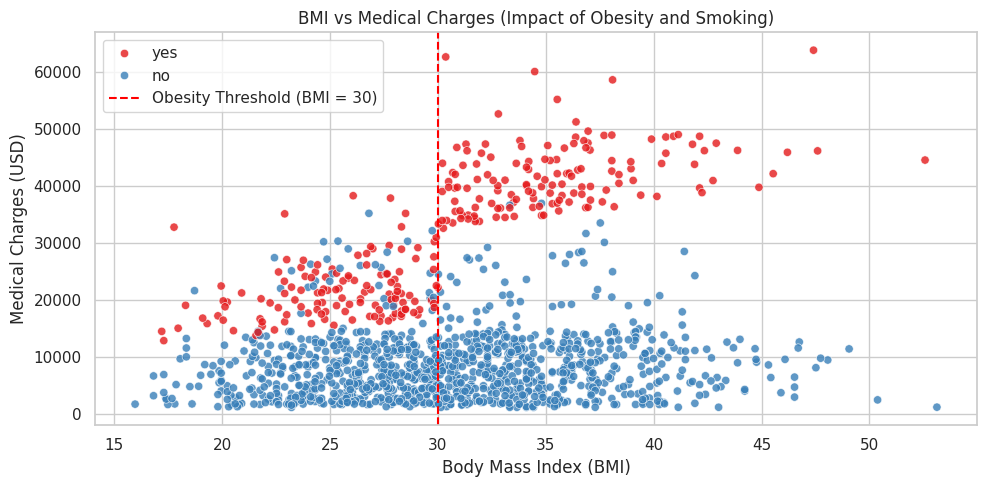

In [ ]:
# --- VISUALIZATION 3: BMI vs. Charges with Trendlines ---
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', palette='Set1', alpha=0.8)
plt.axvline(x=30, color='red', linestyle='--', label='Obesity Threshold (BMI = 30)')
plt.title('BMI vs Medical Charges (Impact of Obesity and Smoking)')
plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('Medical Charges (USD)')
plt.legend()
plt.tight_layout()
plt.savefig('chart3_bmi_vs_charges.png')
plt.show()

**--- CORRELATION ANALYSIS ---**

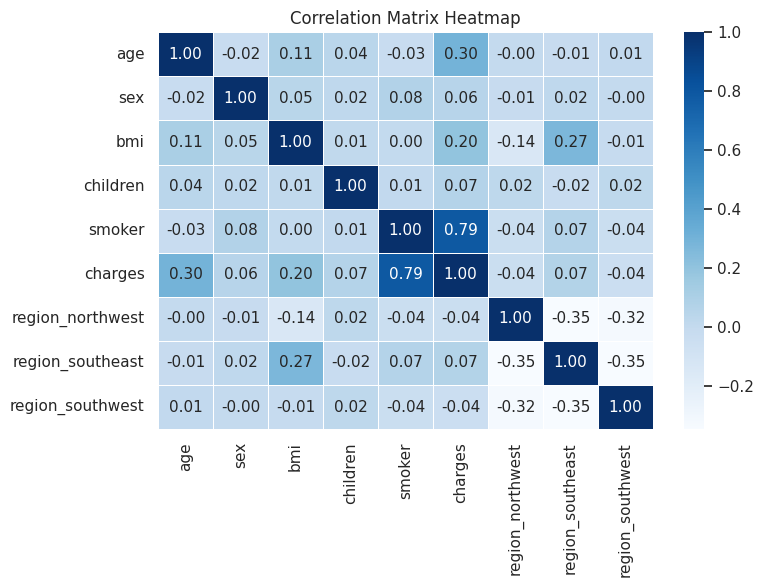

=== CORRELATION WITH TARGET VARIABLE (charges) ===
charges             1.000000
smoker              0.787251
age                 0.299008
bmi                 0.198341
region_southeast    0.073982
children            0.067998
sex                 0.057292
region_northwest   -0.039905
region_southwest   -0.043210
Name: charges, dtype: float64


In [ ]:
# --- CORRELATION ANALYSIS ---
df_corr = df.copy()
df_corr['sex'] = df_corr['sex'].map({'female': 0, 'male': 1})
df_corr['smoker'] = df_corr['smoker'].map({'no': 0, 'yes': 1})
df_corr = pd.get_dummies(df_corr, columns=['region'], drop_first=True, dtype=int)

plt.figure(figsize=(8, 6))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='Blues', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.savefig('correlation_matrix.png')
plt.show()

# Display numerical correlations with the target variable 'charges'
print("=== CORRELATION WITH TARGET VARIABLE (charges) ===")
print(df_corr.corr()['charges'].sort_values(ascending=False))

**Important Observations Discovered****

**A. Impact of Smoking Status (smoker)**

**Strongest Single Predictor:** Smoking status has the single highest correlation with medical charges ($\sim 0.79$).

**Cost Disparity**: Non-smokers generally cluster below $\$15,000$ in annual medical expenses, whereas active smokers consistently experience charges ranging from $\$15,000$ to over $\$40,000$.


**B. Age vs. Medical Charges (age)**

**Steady Linear Increase:** Medical charges exhibit a clear positive correlation ($\sim 0.30$) with age. Across all smoking categories, baseline costs rise predictably as individuals grow older due to cumulative health risks.

**C. BMI & Obesity Interaction (bmi)**

**Non-Linear Compound Effect:** For non-smokers, an increase in BMI leads to a modest increase in costs. However, for active smokers with a BMI over $30$ ($\text{BMI} \ge 30$, the clinical threshold for obesity), medical charges surge drastically into the $\$30,000 - \$50,000+$ bracket.
**Feature Engineering Insight**: Creating an interaction feature (e.g., smoker * bmi) will significantly enhance linear model performance during training.

**D. Region and Sex Influence (region, sex)**  

**Minor Predictive Power:** sex and region display low correlation values ($\le 0.07$) with overall medical charges, indicating that physical health indicators (age, BMI, smoking) drive the vast majority of insurance pricing variance.

# **PHASE 5  —Select and Train the Machine Learning Model**

In [ ]:
# 1. Convert categorical text columns into numeric dummy/indicator variables
X_encoded = pd.get_dummies(X, drop_first=True)

In [ ]:
# 2. Separate Features (X) and Target Variable (y) using the encoded data
X = X_encoded
y = df['charges']

In [ ]:
# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# 4. Model Training
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# 5. Evaluate
y_pred = lr_model.predict(X_test)
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R-squared Score: {r2_score(y_test, y_pred):.4f}")

Mean Squared Error: 33596915.85
R-squared Score: 0.7836


# **PHASE 6  — Evaluate the Model**

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Calculate all required metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared Score (R2): {r2:.4f}\n")

--- Model Evaluation Metrics ---
Mean Absolute Error (MAE): 4181.19
Mean Squared Error (MSE): 33596915.85
Root Mean Squared Error (RMSE): 5796.28
R-squared Score (R2): 0.7836



In [ ]:
# 2. Create Actual vs. Predicted Comparison DataFrame
comparison_df = pd.DataFrame({
    'Actual Charges': y_test.values[:10],
    'Predicted Charges': y_pred[:10]
})
comparison_df['Difference'] = comparison_df['Actual Charges'] - comparison_df['Predicted Charges']

print("--- Actual vs. Predicted Results (First 10 Samples) ---")
print(comparison_df.to_string(index=False))

--- Actual vs. Predicted Results (First 10 Samples) ---
 Actual Charges  Predicted Charges   Difference
     9095.06825        8969.550274   125.517976
     5272.17580        7068.747443 -1796.571643
    29330.98315       36858.410912 -7527.427762
     9301.89355        9454.678501  -152.784951
    33750.29180       26973.173457  6777.118343
     4536.25900       10864.113164 -6327.854164
     2117.33885         170.280841  1947.058009
    14210.53595       16903.450287 -2692.914337
     3732.62510        1092.430936  2640.194164
    10264.44210       11218.343184  -953.901084


# **PHASE 7 — Make Predictions Using the Trained Model**

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd

# 1. Define Input Widgets for User Details
age_input = widgets.IntSlider(value=30, min=18, max=64, description='Age:')
sex_input = widgets.Dropdown(options=['male', 'female'], description='Sex:')
bmi_input = widgets.FloatSlider(value=25.0, min=10.0, max=50.0, step=0.1, description='BMI:')
children_input = widgets.IntSlider(value=0, min=0, max=5, description='Children:')
smoker_input = widgets.Dropdown(options=['yes', 'no'], description='Smoker:')
region_input = widgets.Dropdown(options=['southeast', 'southwest', 'northeast', 'northwest'], description='Region:')

predict_button = widgets.Button(description='Predict Cost', button_style='success')
output_box = widgets.Output()

# 2. Prediction Function linked to the button
def on_predict_clicked(b):
    with output_box:
        clear_output()
input_data = pd.DataFrame({
            'age': [age_input.value],
            'sex': [sex_input.value],
            'bmi': [bmi_input.value],
            'children': [children_input.value],
            'smoker': [smoker_input.value],
            'region': [region_input.value]
        })
        
input_encoded = pd.get_dummies(input_data)
input_encoded = input_encoded.reindex(columns=X.columns, fill_value=0)
predicted_cost = lr_model.predict(input_encoded)[0]
        
print("----------------------------------------")
print(f"  Estimated Medical Insurance Cost: ${predicted_cost:,.2f}")
print("----------------------------------------")

predict_button.on_click(on_predict_clicked)

# 3. Display the Interactive Interface Widget
print("--- MEDICAL INSURANCE COST PREDICTOR APP ---")
display(age_input, sex_input, bmi_input, children_input, smoker_input, region_input, predict_button, output_box)

--- MEDICAL INSURANCE COST PREDICTOR APP ---


IntSlider(value=30, description='Age:', max=64, min=18)

Dropdown(description='Sex:', options=('male', 'female'), value='male')

FloatSlider(value=25.0, description='BMI:', max=50.0, min=10.0)

IntSlider(value=0, description='Children:', max=5)

Dropdown(description='Smoker:', options=('yes', 'no'), value='yes')

Dropdown(description='Region:', options=('southeast', 'southwest', 'northeast', 'northwest'), value='southeast…

Button(button_style='success', description='Predict Cost', style=ButtonStyle())

Output()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import joblib

df = pd.read_csv('insurance.csv')
print("Dataset successfully loaded.")

# Prepare features and target
X = df.drop(columns=['charges'])
y = df['charges']

# Simple label/one-hot encoding for the notebook workflow
X['sex'] = X['sex'].map({'female': 0, 'male': 1})
X['smoker'] = X['smoker'].map({'no': 0, 'yes': 1})
X = pd.get_dummies(X, columns=['region'], drop_first=True)

# Train/Test Split & Model Training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Save the trained model locally in your project folder
joblib.dump(model, 'model.pkl')
print("Model saved successfully as model.pkl!")

Dataset successfully loaded.
Model saved successfully as model.pkl!
